# HE-01

* Contents

1. Patient Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> 1.4 Patient
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    <br> 2.3 Windowing
    3. Slice level Class
    4. Visualization
    
2. Dataset Unit Analysis
    1. Basic Info
    <br> 1.1 Path
    <br> 1.2 Class Mapping
    <br> 1.3 Dataset
    <br> shape, type, spacing, origin, affine, orientation 
    2. 3D CT
    <br> 2.1 Min/Max
    <br> 2.2 HU
    3. Class
    <br> 3.1 Number of Bleed
    <br> 3.2 Type of Bleed
    <br> 3.3 Volume of Bleed
    4. Visualization

3. nnUNet Dataset 구성
<br> class imbalance 고려

## 1. Patients Unit Analysis

In [9]:
import json
import shutil
from pathlib import Path
from collections import Counter

from scipy import ndimage
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### 1. Basic Info

In [10]:
# 1.1 Path
DATA_ROOT = Path("/mnt/hdd4/hjgoh/ich-vlm/data")
DATASET_ROOT = DATA_ROOT / "he-01"

SPLIT_ROOTS = {
    "train": DATASET_ROOT / "train",
    "test": DATASET_ROOT / "test",
}

In [11]:
# 1.2 Class Mapping
# HE-01 마스크는 병변/배경 binary (0/1), subtype 정보 없음
class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}

In [12]:
# 1.3 Dataset
def build_case_map(split: str) -> dict[str, tuple[Path, Path]]:
    ct_root = SPLIT_ROOTS[split] / "ct_scans"
    mask_root = SPLIT_ROOTS[split] / "masks"
    ct_map = {p.stem.split('.')[0]: p for p in sorted(ct_root.glob("*.nii.gz"))}
    mask_map = {p.stem.split('.')[0]: p for p in sorted(mask_root.glob("*.nii.gz"))}
    common = sorted(set(ct_map) & set(mask_map))
    return {cid: (ct_map[cid], mask_map[cid]) for cid in common}

case_maps = {split: build_case_map(split) for split in SPLIT_ROOTS}

print(case_maps)

{'train': {'ICH0501': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0501.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/ICH0501.nii.gz')), 'ICH0502': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0502.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/ICH0502.nii.gz')), 'ICH0503': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0503.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/ICH0503.nii.gz')), 'ICH0504': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0504.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/ICH0504.nii.gz')), 'ICH0505': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0505.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/ICH0505.nii.gz')), 'ICH0506': (PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/ct_scans/ICH0506.nii.gz'), PosixPath('/mnt/hdd4/hjgoh/ich-vlm/data/he-01/train/masks/

In [13]:
for split, cases in case_maps.items():
    print(f"{split}: {len(cases)} cases")

train: 284 cases
test: 52 cases


In [31]:
# 1.4 Patient
split = "train"
case_id = sorted(case_maps[split])[200]
ct_path, mask_path = case_maps[split][case_id]

img_nib = nib.load(str(ct_path))
mask_nib = nib.load(str(mask_path))
img_arr = img_nib.get_fdata() # 이게 모든 데이터에 대해서 만들 수 있는 게 아님 
mask_arr = mask_nib.get_fdata()

print("case:", case_id, f"({split})")
print("이미지 shape:", img_arr.shape, "| dtype:", img_nib.get_data_dtype())
print("마스크 shape:", mask_arr.shape, "| dtype:", mask_nib.get_data_dtype())
print("spacing (zooms):", img_nib.header.get_zooms())
print("affine:\n", img_nib.affine)
print("orientation:", nib.aff2axcodes(img_nib.affine))

case: ICH0835 (train)
이미지 shape: (512, 512, 4) | dtype: float32
마스크 shape: (512, 512, 4) | dtype: uint8
spacing (zooms): (np.float32(0.468), np.float32(0.468), np.float32(3.0))
affine:
 [[0.46799999 0.         0.         0.        ]
 [0.         0.46799999 0.         0.        ]
 [0.         0.         3.         0.        ]
 [0.         0.         0.         1.        ]]
orientation: ('R', 'A', 'S')


In [15]:
print(img_nib)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (512, 512, 5)
affine:
[[0.46799999 0.         0.         0.        ]
 [0.         0.46799999 0.         0.        ]
 [0.         0.         3.         0.        ]
 [0.         0.         0.         1.        ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  3 512 512   5   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [1.    0.468 0.468 3.    1.    1.    1.    1.   ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin    

### 2. 3D CT

In [18]:
flat = img_arr.astype(np.float32).ravel()
percentiles = np.percentile(flat, [0, 0.5, 1, 5, 50, 95, 99, 99.5, 100])
print("min/max:", flat.min(), flat.max())
print("percentiles:", percentiles)

min/max: -1024.0 1788.0
percentiles: [-1024. -1017. -1013. -1006.  -951.   381.   924.  1036.  1788.]


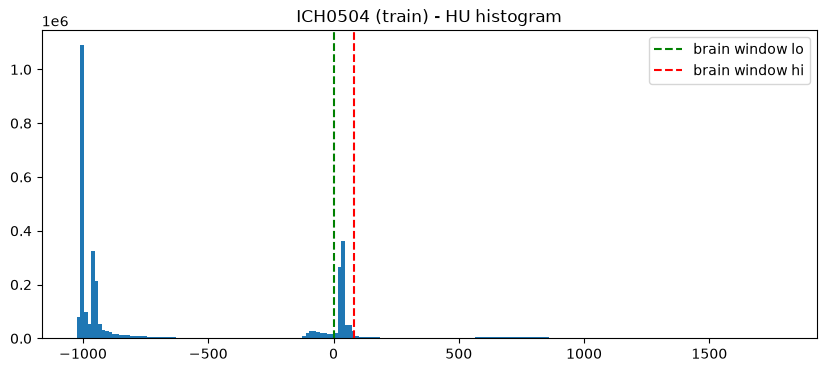

In [19]:
plt.figure(figsize=(10, 4))
plt.hist(img_arr.astype(np.float32).ravel(), bins=200)
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend() 
plt.title(f'{case_id} ({split}) - HU histogram')
plt.show()

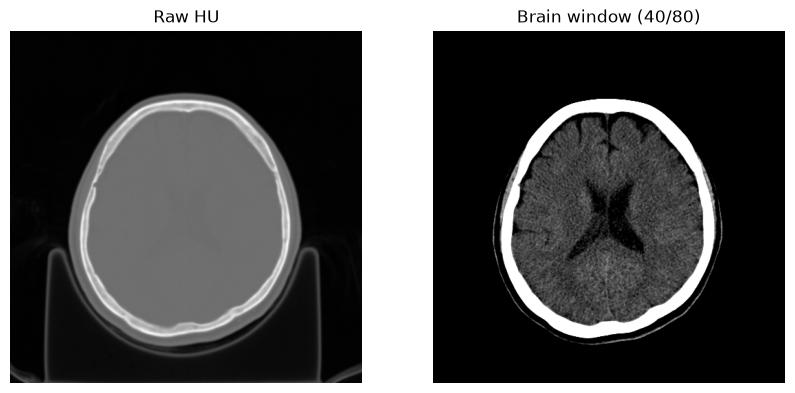

In [32]:
def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

num_slices = img_arr.shape[2]
mid = num_slices // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_arr[:, :, mid], cmap='gray'); axes[0].set_title('Raw HU'); axes[0].axis('off')
axes[1].imshow(apply_window(img_arr[:, :, mid]), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Brain window (40/80)'); axes[1].axis('off')
plt.show()

### 3. Slice level hematoma pixel

In [33]:
# ID ICH0501에서 각 슬라이스 별 병변 픽셀의 개수 센 것 
rows = []
for z in range(mask_arr.shape[2]):            
    fg = int((mask_arr[:, :, z] > 0).sum())
    rows.append({'slice': z, 'fg_voxels(mask)': fg})
df_slices = pd.DataFrame(rows)
display(df_slices)

,slice,fg_voxels(mask)
0,0,89
1,1,80
2,2,74
3,3,49


### 4. Visualization

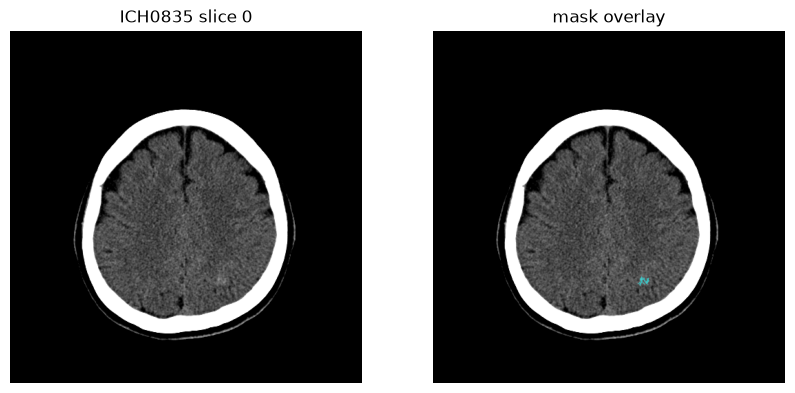

In [34]:
best_z = int(df_slices['fg_voxels(mask)'].idxmax())
windowed_slice = apply_window(img_arr[:, :, best_z])
mask_slice = mask_arr[:, :, best_z]
mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)

n_classes_1cls = max(class_colors_1cls.keys()) + 1
colors_rgb_1cls = np.zeros((n_classes_1cls, 3))
for cls, rgb in class_colors_1cls.items():
    colors_rgb_1cls[cls] = np.array(rgb) / 255
custom_cmap_1cls = ListedColormap(colors_rgb_1cls)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(windowed_slice, cmap='gray'); axes[0].set_title(f'{case_id} slice {best_z}'); axes[0].axis('off')
axes[1].imshow(windowed_slice, cmap='gray')
axes[1].imshow(mask_overlay, cmap=custom_cmap_1cls, vmin=0, vmax=n_classes_1cls - 1, alpha=0.5)
axes[1].set_title('mask overlay'); axes[1].axis('off')
plt.show()

In [ ]:
from ctviewer import CTViewer
CTViewer(img_arr)

## 2. Dataset Unit Analysis

### 1. Basic Info
#### 1.3 Dataset

In [26]:
# 1.3 Dataset (shape/spacing/depth 분포)
meta_rows = []
slice_num = 0
for split, cases in case_maps.items():
    for cid, (ct_p, _) in cases.items():
        img = nib.load(str(ct_p))
        meta_rows.append({
            'split': split,
            'case': cid,
            'shape': img.shape,
            'depth(slices)': img.shape[2],
            'spacing': img.header.get_zooms(),
        })

        slice_num += img.shape[2]
df_meta = pd.DataFrame(meta_rows)
display(df_meta.head())

print("\nsplit별 케이스 수:\n", df_meta['split'].value_counts())
print("\ndepth(슬라이스 수) 분포:\n", df_meta['depth(slices)'].describe())
print(f"Total slices: {slice_num}")

,split,case,shape,depth(slices),spacing
0,train,ICH0501,"(512, 512, 5)",5,"(0.468, 0.468, 3.0)"
1,train,ICH0502,"(512, 512, 7)",7,"(0.468, 0.468, 3.0)"
2,train,ICH0503,"(512, 512, 11)",11,"(0.468, 0.468, 3.0)"
3,train,ICH0504,"(512, 512, 13)",13,"(0.468, 0.468, 3.0)"
4,train,ICH0505,"(512, 512, 11)",11,"(0.468, 0.468, 3.0)"



split별 케이스 수:
 split
train    284
test      52
Name: count, dtype: int64

depth(슬라이스 수) 분포:
 count    336.000000
mean      11.705357
std        6.206840
min        1.000000
25%        7.000000
50%       11.000000
75%       15.000000
max       39.000000
Name: depth(slices), dtype: float64
Total slices: 3933


### 2. 3D CT

In [27]:
# 2.1 Min/Max
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

hu_rows = []
for split, cases in case_maps.items():
    for cid, (ct_p, _) in cases.items():
        arr = nib.load(str(ct_p)).get_fdata().astype(np.float32)
        flat = arr.ravel()
        p = np.percentile(flat, [0.5, 1, 5, 50, 95, 99, 99.5])
        hu_rows.append({
            'split': split, 'case': cid, 'min': flat.min(), 'max': flat.max(),
            'p0.5': p[0], 'p1': p[1], 'p5': p[2], 'p50': p[3], 'p95': p[4], 'p99': p[5], 'p99.5': p[6],
        })
df_hu = pd.DataFrame(hu_rows)

df_hu_train = df_hu[df_hu['split'] == 'train'].drop(columns=['split', 'case'])
df_hu_test = df_hu[df_hu['split'] == 'test'].drop(columns=['split', 'case'])

print("=== Train ===")
display(df_hu_train.describe())

print("=== Test ===")
display(df_hu_test.describe())

=== Train ===


,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,284.00,284.00,284.00,284.00,284.00,284.00,284.00,284.00,284.00
mean,-1197.63,1754.68,-1192.98,-1189.30,-1184.87,-908.88,444.90,1162.14,1284.34
std,437.83,291.23,439.71,441.17,442.94,84.74,161.89,204.77,196.71
min,-3024.00,1036.00,-3024.00,-3024.00,-3024.00,-1001.00,33.00,257.00,377.00
25%,-1024.00,1577.00,-1024.00,-1017.00,-1010.00,-950.00,328.00,1046.75,1185.25
50%,-1024.00,1695.00,-1018.00,-1013.00,-1007.00,-922.00,433.00,1181.50,1311.50
75%,-1024.00,1844.25,-1013.00,-1010.00,-1005.00,-900.00,553.25,1288.50,1402.25
max,-1000.00,2976.00,-1000.00,-1000.00,-1000.00,-44.00,988.00,2038.00,2201.00


=== Test ===


,min,max,p0.5,p1,p5,p50,p95,p99,p99.5
count,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00,52.00
mean,-1751.69,1733.44,-1749.13,-1748.13,-1746.58,-917.69,417.75,1221.67,1338.77
std,508.06,247.34,511.80,513.26,515.53,69.64,182.74,188.48,167.12
min,-3024.00,1314.00,-3024.00,-3024.00,-3024.00,-985.00,62.00,803.00,919.00
25%,-2048.00,1604.75,-2048.00,-2048.00,-2048.00,-976.00,287.50,1053.50,1207.00
50%,-2048.00,1677.00,-2048.00,-2048.00,-2048.00,-932.00,391.00,1230.00,1369.50
75%,-1024.00,1812.50,-1019.75,-1014.75,-1009.00,-889.75,532.50,1381.75,1472.00
max,-1024.00,2976.00,-1010.00,-1009.00,-1004.00,-661.00,944.00,1620.00,1679.00


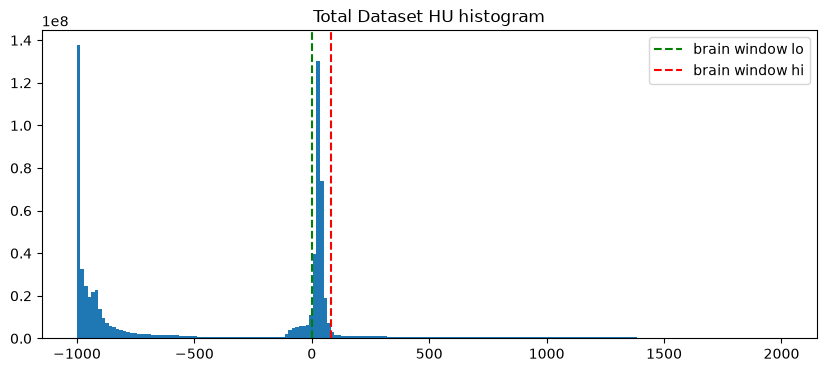

In [28]:
# 2.2 HU (전체 데이터셋 histogram, 케이스별 histogram을 누적)
hist_counts = None
bin_edges = np.linspace(-1000, 2000, 201)
for split, cases in case_maps.items():
    for cid, (ct_p, _) in cases.items():
        arr = nib.load(str(ct_p)).get_fdata().astype(np.float32)
        counts, _ = np.histogram(arr.ravel(), bins=bin_edges)
        hist_counts = counts if hist_counts is None else hist_counts + counts

plt.figure(figsize=(10, 4))
plt.bar(bin_edges[:-1], hist_counts, width=np.diff(bin_edges), align='edge')
plt.axvline(0, color='green', linestyle='--', label='brain window lo')
plt.axvline(80, color='red', linestyle='--', label='brain window hi')
plt.legend()
plt.title('Total Dataset HU histogram')
plt.show()

### 3. Class

### 4. Visualization

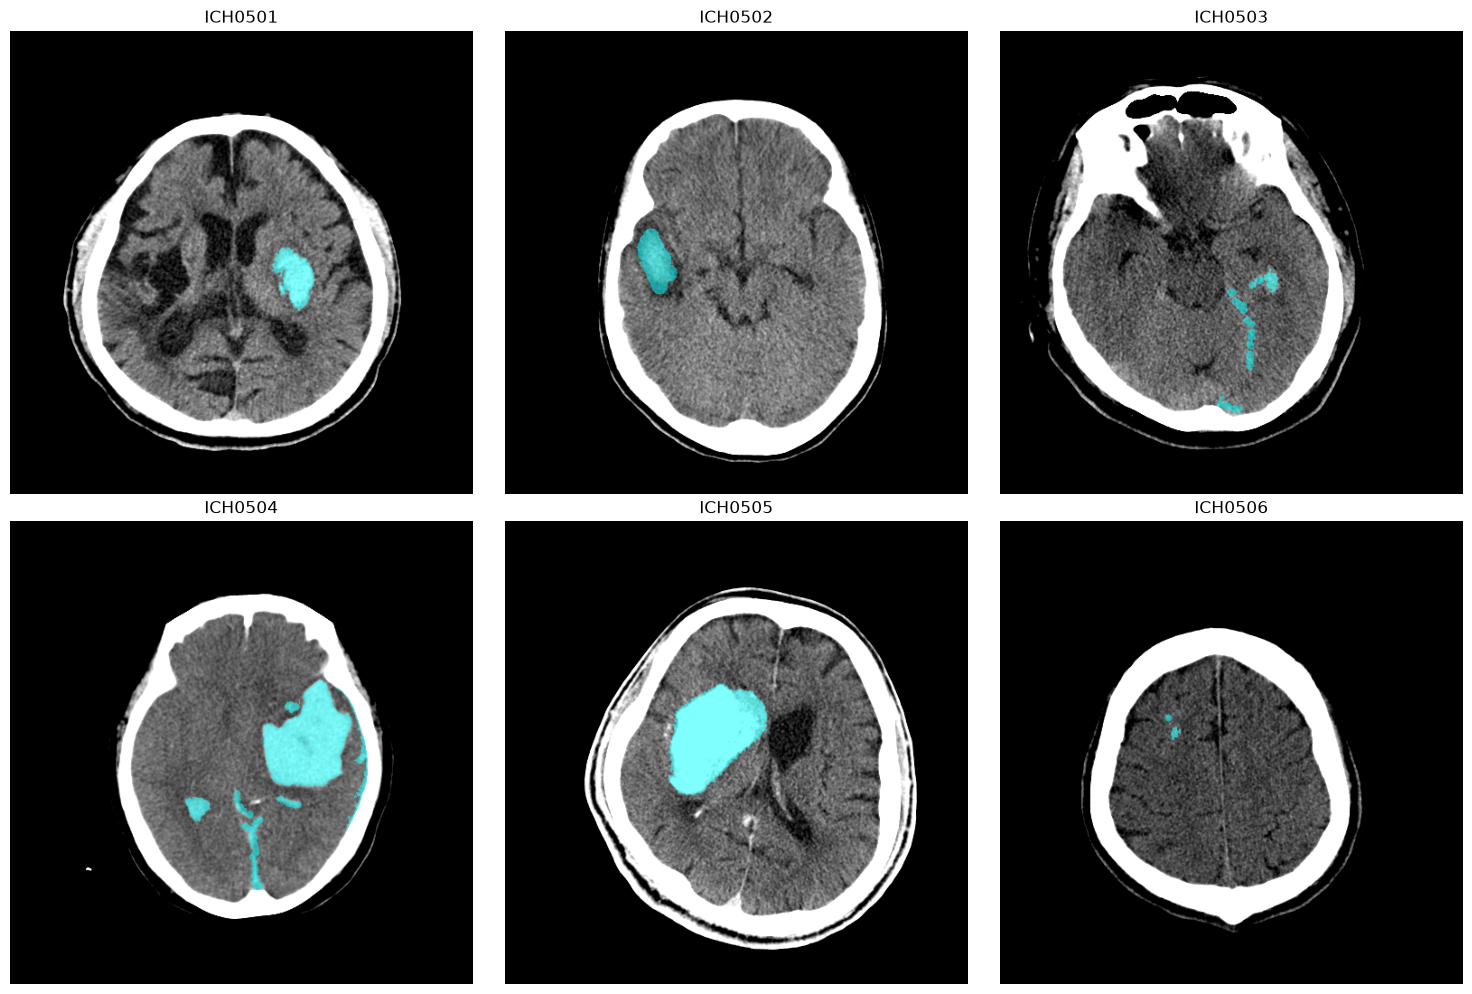

In [36]:
sample_cases = list(case_maps['train'].items())[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (cid, (ct_p, mask_p)) in zip(axes.ravel(), sample_cases):
    arr = nib.load(str(ct_p)).get_fdata()
    marr = nib.load(str(mask_p)).get_fdata()
    fg_per_slice = marr.sum(axis=(0, 1))
    z = int(fg_per_slice.argmax())

    windowed = apply_window(arr[:, :, z])
    overlay = np.ma.masked_where(marr[:, :, z] == 0, marr[:, :, z])

    ax.imshow(windowed, cmap='gray')
    ax.imshow(overlay, cmap=custom_cmap_1cls, vmin=0, vmax=1, alpha=0.5)
    ax.set_title(cid)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. nnUNet Dataset 구성

In [38]:
# train -> imagesTr/labelsTr, test -> imagesTs (라벨 없음)
NNUNET_RAW = Path("/mnt/hdd4/hjgoh/ich-vlm/nnUNet/nnUNet_raw")  # .gitignore의 /nnUNet 규칙에 포함됨
TASK_NAME = "Dataset001_HE01ICH"
task_dir = NNUNET_RAW / TASK_NAME
(task_dir / "imagesTr").mkdir(parents=True, exist_ok=True)
(task_dir / "labelsTr").mkdir(parents=True, exist_ok=True)
(task_dir / "imagesTs").mkdir(parents=True, exist_ok=True)
(task_dir / "labelsTs").mkdir(parents=True, exist_ok=True)

for cid, (ct_p, mask_p) in case_maps["train"].items():
    shutil.copy(ct_p, task_dir / "imagesTr" / f"{cid}_0000.nii.gz")
    shutil.copy(mask_p, task_dir / "labelsTr" / f"{cid}.nii.gz")

for cid, (ct_p, mask_p) in case_maps["test"].items():
    shutil.copy(ct_p, task_dir / "imagesTs" / f"{cid}_0000.nii.gz")
    shutil.copy(mask_p, task_dir / "labelsTs" / f"{cid}.nii.gz")

dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "ich": 1},
    "numTraining": len(case_maps["train"]),
    "file_ending": ".nii.gz",
}
with open(task_dir / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

print("nnUNet raw dataset 구성 완료:", task_dir)

nnUNet raw dataset 구성 완료: /mnt/hdd4/hjgoh/ich-vlm/nnUNet/nnUNet_raw/Dataset001_HE01ICH


* 모든 케이스가 병변이 있는 슬라이스만 모아 만든 볼륨
<br> "완전히 정상인" 케이스는 없음 
<br> 볼륨 내에서 병변 voxel 비율 자체 작음

* nnU-Net은 기본적으로 학습 patch의 `oversample_foreground_percent`(기본 0.33) 비율만큼 
<br> foreground가 포함된 patch를 강제로 샘플링하므로 별도 조치 없이도 어느 정도 완화. 
<br> 그래도 불균형이 심하면:
    - `nnUNetTrainer`를 상속해 `oversample_foreground_percent`를 0.5~0.66으로 높이거나
    - Dice+CE 대신 Dice+Focal loss로 교체 